# Notebook 02 — Sensitivity to Recalibration Frequency

**Research question**: How robust is the JM-XGB framework's performance to the choice of model recalibration frequency?

Shu et al. (2024) use **biannual** (semi-annual) recalibration. This notebook compares:

| Frequency | Recalibration months |
|-----------|---------------------|
| Quarterly  | Jan, Apr, Jul, Oct  |
| Semi-annual (paper) | Jan, Jul |
| Annual     | Jan                 |

We evaluate across all three portfolio models (MinVar, MV, EW) and the 0/1 individual-asset strategy.

**Hypothesis**: If the regime structure is economically meaningful rather than a statistical artefact, performance should be largely robust to moderate changes in recalibration frequency.

In [11]:
import sys, os, pickle, warnings
from pathlib import Path

for _thread_var in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ.setdefault(_thread_var, '1')

_here = Path.cwd().resolve()
_repo_root = next(
    (p for p in (_here, _here.parent, _here.parent.parent)
     if (p / "src" / "config" / "settings.py").is_file()),
    _here.parent,
)
sys.path.insert(0, str(_repo_root))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.utils.helpers import setup_logging, wealth_curve
setup_logging()

RESULTS_DIR = _repo_root / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Re-use the data already loaded in notebook 01 ────────────────────
from src.config.settings import (
    ASSETS, ASSET_TICKERS, FRED_SERIES,
    DATA_START, DATA_END, TEST_START, TEST_END
)
from src.data.loader import DataLoader
from src.data.preprocessor import DataPreprocessor

loader = DataLoader()
prices = loader.load_prices(ASSET_TICKERS, start=DATA_START, end=DATA_END)
fred   = loader.load_fred(FRED_SERIES,     start=DATA_START, end=DATA_END)

prep = DataPreprocessor()
excess_returns, rf_daily, fred_aligned = prep.prepare(prices, fred)
total_returns = prices.pct_change().reindex(excess_returns.index).ffill()

print('Data loaded. Testing period:', TEST_START, '→', TEST_END)

2026-04-27 10:21:24 | ERROR    | asyncio | Task was destroyed but it is pending!
task: <Task pending name='Task-173' coro=<_async_in_context.<locals>.run_in_context() done, defined at /usr/local/lib/python3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-174' coro=<Kernel.shell_main() running at /usr/local/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /usr/local/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py:563]>
2026-04-27 10:21:24 | ERROR    | asyncio | Task was destroyed but it is pending!
task: <Task pending name='Task-174' coro=<Kernel.shell_main() running at /usr/local/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>
2026-04-27 10:21:24 | INFO     | src.data.loader | Loading prices from cache: /home/researcher/app/data/raw/prices_1991-01-01_2023-12-31.pkl
2026-04-27 10:21:24 | INFO     | src.data.loader | Loading FRED data

Data loaded. Testing period: 2007-01-01 → 2023-12-31


## 1 · Define Recalibration Schedules

In [12]:
# Run annual first, then paper semi-annual, then quarterly.
# Caches: results/regime_annual.pkl, regime_semi_annual.pkl, regime_quarterly.pkl.
# (Notebook 05 still respects THESIS_FAST_NOTEBOOKS for a shorter asset loop.)
REBAL_SCHEDULES = {
    "Annual":      (1,),
    "Semi-Annual": (1, 7),
    "Quarterly":   (1, 4, 7, 10),
}

## 2 · Generate Regime Forecasts for Each Schedule

Each schedule runs the full JM-XGB framework (Algorithm 1 + 2) with a different `rebal_months` argument.  
Results are cached per schedule.

In [13]:
from time import perf_counter
import gc
import os

for _thread_var in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ.setdefault(_thread_var, '1')

from src.models.regime_framework import RegimeFramework

required_data_vars = ['prices', 'fred', 'excess_returns', 'rf_daily', 'fred_aligned', 'total_returns']
missing_data_vars = [name for name in required_data_vars if name not in globals()]
if missing_data_vars:
    raise RuntimeError(
        'Run the first data-loading cell before this recalibration block. '
        f'Missing variables: {missing_data_vars}'
    )


# Keep outer parallelism conservative. XGBoost also uses native threads,
# and nested parallelism is what tends to trigger notebook/Docker OOMs.
ASSET_JOBS = int(os.environ.get('THESIS_ASSET_JOBS', '1'))
XGB_N_JOBS = int(os.environ.get('THESIS_XGB_N_JOBS', '1'))

CHECKPOINT_DIR = RESULTS_DIR / 'regime_asset_checkpoints'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)


def _schedule_cache_path(sched_name: str) -> Path:
    slug = sched_name.lower().replace('-', '_')
    return RESULTS_DIR / f'regime_{slug}.pkl'


def _asset_checkpoint_path(cache_prefix: str, asset: str) -> Path:
    safe_asset = ''.join(ch if ch.isalnum() or ch in ('-', '_') else '_' for ch in asset)
    return CHECKPOINT_DIR / f'{cache_prefix}_{safe_asset}.pkl'


def _load_pickle(path: Path):
    with open(path, 'rb') as f:
        return pickle.load(f)


def _save_pickle(path: Path, payload) -> None:
    with open(path, 'wb') as f:
        pickle.dump(payload, f)


def _seed_from_nb01_if_available(sched_name: str, months: tuple[int, ...], cache_file: Path):
    nb01_fc = RESULTS_DIR / 'regime_forecasts.pkl'
    nb01_lam = RESULTS_DIR / 'optimal_lambdas.pkl'
    if not (
        sched_name == 'Semi-Annual'
        and months == (1, 7)
        and nb01_fc.is_file()
        and nb01_lam.is_file()
    ):
        return None

    print(f'Seeding [{sched_name}] from notebook 01 caches …')
    fc = _load_pickle(nb01_fc)
    lams = _load_pickle(nb01_lam)
    _save_pickle(cache_file, (fc, lams))
    print(f'  → Saved to {cache_file}')
    return fc, lams


regime_by_schedule = {}
lambdas_by_schedule = {}

for sched_name, months in REBAL_SCHEDULES.items():
    cache_file = _schedule_cache_path(sched_name)

    if cache_file.exists():
        print(f'Loading cached [{sched_name}] …', flush=True)
        regime_by_schedule[sched_name], lambdas_by_schedule[sched_name] = _load_pickle(cache_file)
        continue

    seeded = _seed_from_nb01_if_available(sched_name, months, cache_file)
    if seeded is not None:
        fc, lams = seeded
        regime_by_schedule[sched_name] = fc
        lambdas_by_schedule[sched_name] = lams
        continue

    cached_assets = [a for a in ASSETS if _asset_checkpoint_path(cache_file.stem, a).is_file()]
    print(
        f'Running [{sched_name}] (rebal months={months}, asset_jobs={ASSET_JOBS}, xgb_n_jobs={XGB_N_JOBS}) …',
        flush=True,
    )
    print(
        f'  Asset checkpoints: {len(cached_assets)}/{len(ASSETS)} in {CHECKPOINT_DIR}',
        flush=True,
    )
    started = perf_counter()
    fw = RegimeFramework(
        excess_returns = excess_returns,
        rf             = rf_daily,
        fred_aligned   = fred_aligned,
        assets         = ASSETS,
        rebal_months   = months,
        asset_jobs     = ASSET_JOBS,
        xgb_n_jobs     = XGB_N_JOBS,
    )
    fc, lams = fw.run(
        test_start=TEST_START,
        test_end=TEST_END,
        asset_cache_dir=CHECKPOINT_DIR,
        cache_prefix=cache_file.stem,
    )
    regime_by_schedule[sched_name] = fc
    lambdas_by_schedule[sched_name] = lams
    _save_pickle(cache_file, (fc, lams))
    elapsed_s = perf_counter() - started
    print(f'[{sched_name}] finished in {elapsed_s / 60:.1f} min')
    print(f'  → Saved to {cache_file}')
    del fw
    gc.collect()

regime_by_schedule = {name: regime_by_schedule[name] for name in REBAL_SCHEDULES}
lambdas_by_schedule = {name: lambdas_by_schedule[name] for name in REBAL_SCHEDULES}

print('Done.')

Loading cached [Annual] …
Loading cached [Semi-Annual] …
Loading cached [Quarterly] …
Done.


## 3 · 0/1 Strategy — Per-Asset Sharpe by Schedule

In [14]:
from src.models.regime_framework import _sharpe_01_strategy

er_test = excess_returns.loc[TEST_START:TEST_END]
rf_test = rf_daily.loc[TEST_START:TEST_END]

sharpe_table = pd.DataFrame(index=ASSETS, columns=list(REBAL_SCHEDULES.keys()))

for sched_name, regime_fc in regime_by_schedule.items():
    for asset in ASSETS:
        fc_a = regime_fc[asset].reindex(er_test.index).ffill()
        sr   = _sharpe_01_strategy(fc_a, er_test[asset], rf_test)
        sharpe_table.loc[asset, sched_name] = round(sr, 3)

sharpe_table = sharpe_table.astype(float)
print('=== Strategy Sharpe Ratio by Recalibration Frequency ===')
print(sharpe_table.to_string())
sharpe_table.to_csv(RESULTS_DIR / 'sens_01_sharpe_by_schedule.csv')

=== 0/1 Strategy Sharpe Ratio by Recalibration Frequency ===
           Annual  Semi-Annual  Quarterly
LargeCap    0.424        0.343      0.482
MidCap      0.589        0.720      0.642
SmallCap    0.421        0.430      0.426
EAFE        0.090        0.149      0.311
EM          0.045       -0.018     -0.168
AggBond     0.218       -0.028      0.352
Treasury    0.369        0.199      0.226
HighYield  -0.083        0.088      0.236
Corporate   0.272        0.050      0.362
REIT        0.258        0.248      0.324
Commodity   0.248        0.220      0.173
Gold        0.154        0.337      0.272


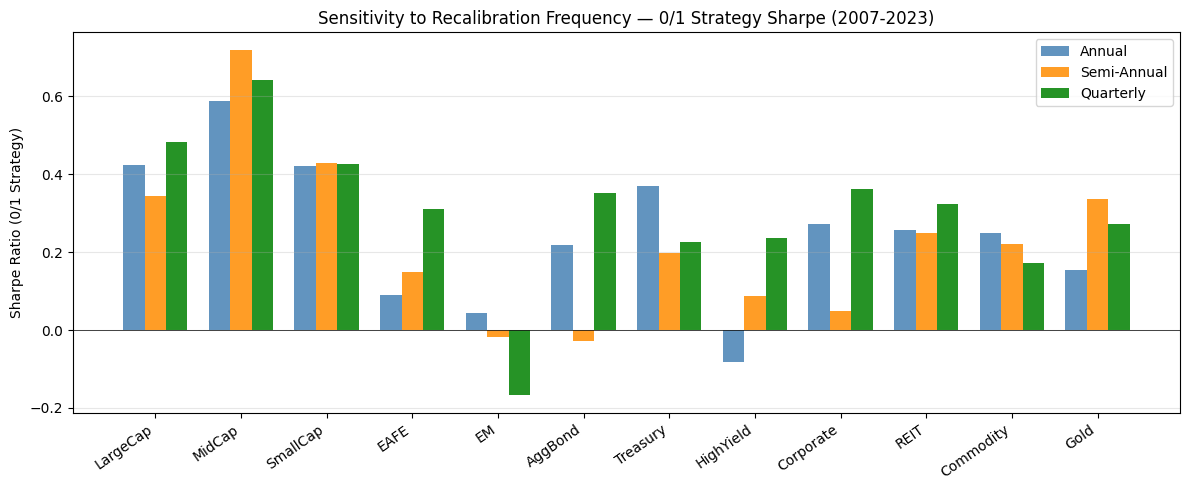

In [15]:
# Visualise
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(ASSETS))
width = 0.25
colors = ['steelblue', 'darkorange', 'green']

for i, (sched_name, color) in enumerate(zip(REBAL_SCHEDULES.keys(), colors)):
    vals = sharpe_table[sched_name].values
    ax.bar(x + i * width, vals, width, label=sched_name, color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(ASSETS, rotation=35, ha='right')
ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Sharpe Ratio')
ax.set_title('Sensitivity to Recalibration Frequency — Strategy Sharpe (2007-2023)')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'sens_fig1_01sharpe_by_schedule.png', dpi=150)
plt.show()

## 4 · Portfolio Performance by Schedule

In [16]:
from src.backtest.engine import BacktestEngine
from src.portfolio.strategies import build_strategy
from src.backtest.metrics import strategy_table

engine = BacktestEngine(
    excess_returns = excess_returns,
    total_returns  = total_returns,
    rf             = rf_daily,
    assets         = ASSETS,
)

# Strategies that use regime forecasts
regime_strategies = ['MinVar(JM-XGB)', 'EW(JM-XGB)']

port_results_by_schedule = {}

for sched_name, regime_fc in regime_by_schedule.items():
    port_cache = RESULTS_DIR / f'port_{sched_name.lower().replace("-","_")}.pkl'

    if port_cache.exists():
        with open(port_cache, 'rb') as f:
            port_results_by_schedule[sched_name] = pickle.load(f)
    else:
        strats = {name: build_strategy(name, ASSETS) for name in regime_strategies}
        results = engine.run_all(
            strategies       = strats,
            test_start       = TEST_START,
            test_end         = TEST_END,
            regime_forecasts = regime_fc,
        )
        port_results_by_schedule[sched_name] = results
        with open(port_cache, 'wb') as f:
            pickle.dump(results, f)

    metrics = {f'{name} [{sched_name}]': r['metrics']
               for name, r in port_results_by_schedule[sched_name].items()}
    print(f'\n=== {sched_name} ===')
    print(strategy_table(metrics).to_string())


=== Annual ===
                        Return Volatility Sharpe     MDD Calmar Turnover Leverage
MinVar(JM-XGB) [Annual]   3.5%       5.3%   0.65  -10.7%   0.32     3.23     0.93
EW(JM-XGB) [Annual]       5.7%      11.3%   0.50  -25.4%   0.22    17.63     0.96

=== Semi-Annual ===
                             Return Volatility Sharpe     MDD Calmar Turnover Leverage
MinVar(JM-XGB) [Semi-Annual]   3.0%       5.4%   0.56   -9.6%   0.31     2.91     0.93
EW(JM-XGB) [Semi-Annual]       6.2%      11.6%   0.53  -29.6%   0.21    17.40     0.96

=== Quarterly ===
                           Return Volatility Sharpe     MDD Calmar Turnover Leverage
MinVar(JM-XGB) [Quarterly]   2.8%       5.4%   0.52  -12.1%   0.23     2.34     0.94
EW(JM-XGB) [Quarterly]       5.4%      11.3%   0.48  -24.9%   0.22    15.36     0.96


## 5 · Wealth Curve Comparison

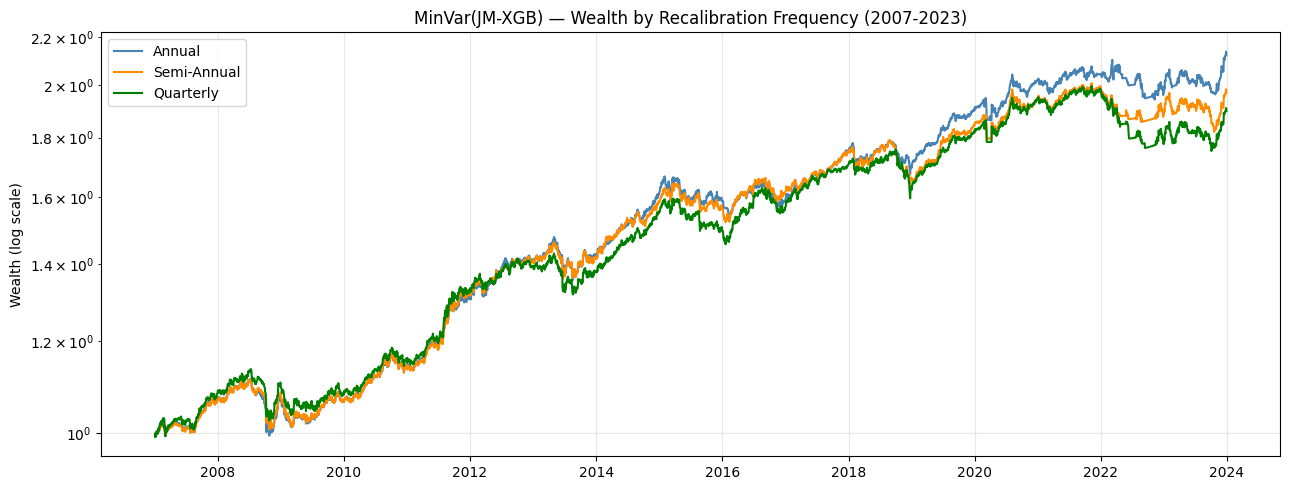

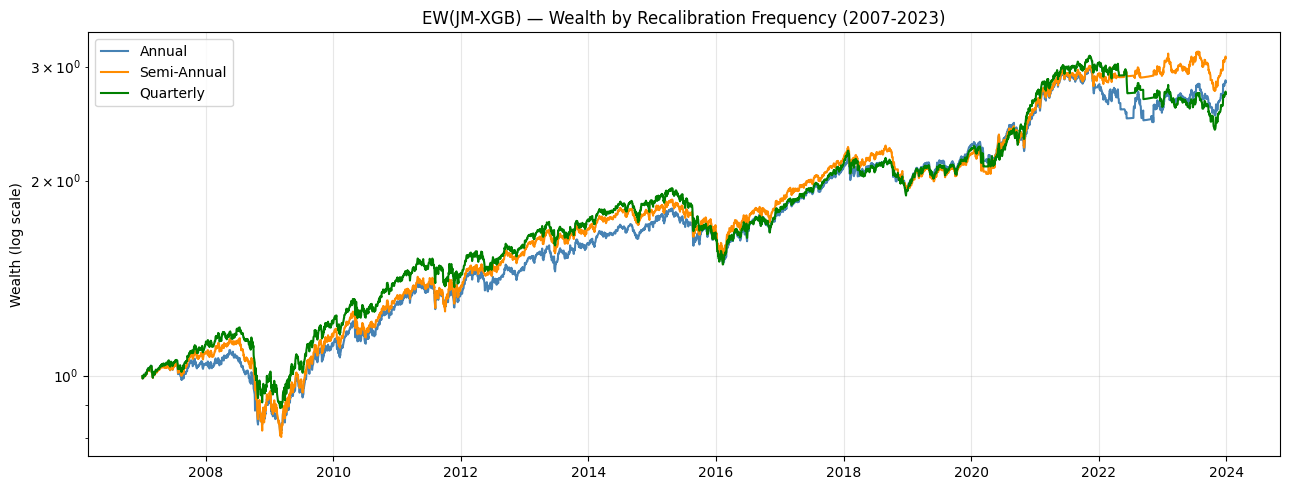

In [17]:
for strat_name in regime_strategies:
    fig, ax = plt.subplots(figsize=(13, 5))
    colors  = ['steelblue', 'darkorange', 'green']

    for (sched_name, results), color in zip(port_results_by_schedule.items(), colors):
        if strat_name in results:
            ret = results[strat_name]['port_returns']
            wc  = wealth_curve(ret)
            ax.plot(wc.index, wc.values, label=sched_name, color=color, lw=1.5)

    ax.set_yscale('log')
    ax.set_title(f'{strat_name} — Wealth by Recalibration Frequency (2007-2023)')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_ylabel('Wealth (log scale)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.tight_layout()
    fname = f'sens_wealth_{strat_name.replace("(","").replace(")","").replace("/","").replace(" ","_")}.png'
    plt.savefig(RESULTS_DIR / fname, dpi=150)
    plt.show()

## 6 · Summary: Sharpe Ratio Heatmap

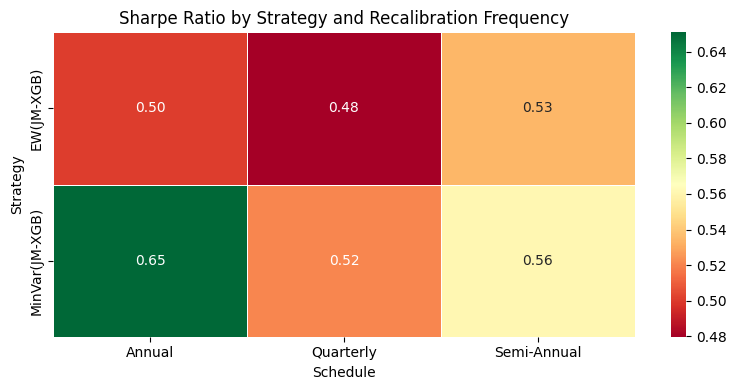


Coefficient of Variation of Sharpe across schedules (lower = more robust):
Strategy
EW(JM-XGB)        0.055
MinVar(JM-XGB)    0.115


In [18]:
import seaborn as sns

summary_rows = []
for sched_name, results in port_results_by_schedule.items():
    for strat_name, res in results.items():
        summary_rows.append({
            'Schedule': sched_name,
            'Strategy': strat_name,
            'Sharpe':   res['metrics']['Sharpe'],
            'MDD':      res['metrics']['MDD'],
            'Return':   res['metrics']['Return'],
        })

summary_df = pd.DataFrame(summary_rows)
pivot_sr   = summary_df.pivot(index='Strategy', columns='Schedule', values='Sharpe')

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    pivot_sr.astype(float),
    annot=True, fmt='.2f', cmap='RdYlGn',
    ax=ax, linewidths=0.5,
)
ax.set_title('Sharpe Ratio by Strategy and Recalibration Frequency')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'sens_heatmap_sharpe.png', dpi=150)
plt.show()

print('\nCoefficient of Variation of Sharpe across schedules (lower = more robust):')
cv = pivot_sr.astype(float).std(axis=1) / pivot_sr.astype(float).mean(axis=1)
print(cv.round(3).to_string())

summary_df.to_csv(RESULTS_DIR / 'sens_summary_by_schedule.csv', index=False)

## 7 · Turnover Analysis

Higher recalibration frequency should increase model-update costs but may reduce per-period position drift.

In [19]:
turnover_rows = []
for sched_name, results in port_results_by_schedule.items():
    for strat_name, res in results.items():
        monthly_to = res['turnover'].resample('ME').sum()
        turnover_rows.append({
            'Schedule': sched_name,
            'Strategy': strat_name,
            'Avg Monthly Turnover': monthly_to.mean(),
            'Ann Turnover':         res['metrics']['Turnover'],
        })

turnover_df = pd.DataFrame(turnover_rows)
print('=== Turnover by Schedule and Strategy ===')
print(turnover_df.pivot(index='Strategy', columns='Schedule', values='Ann Turnover').round(2).to_string())

=== Turnover by Schedule and Strategy ===
Schedule        Annual  Quarterly  Semi-Annual
Strategy                                      
EW(JM-XGB)       17.63      15.36        17.40
MinVar(JM-XGB)    3.23       2.34         2.91


## 8 · Formal comparison across recalibration frequencies

**Friedman test:** treats each asset as a block and tests whether 0/1 **Sharpe ratios** differ across the three schedules (Quarterly, Semi-Annual, Annual).

**Pairwise schedule gap:** bootstrap distribution of mean cross-asset improvement from the **paper** semi-annual baseline vs another schedule.

In [20]:
from scipy.stats import friedmanchisquare

scheds = list(REBAL_SCHEDULES.keys())
cols = [sharpe_table[s].values for s in scheds]
fr = friedmanchisquare(*cols)
print("Friedman chi-square:", round(fr.statistic, 4), "p-value:", round(fr.pvalue, 4))
baseline_name = "Semi-Annual" if "Semi-Annual" in scheds else scheds[0]
for other in scheds:
    if other == baseline_name:
        continue
    delta = (sharpe_table[other] - sharpe_table[baseline_name]).astype(float)
    rng = np.random.default_rng(1)
    B = 2000
    boot_m = []
    arr = delta.values
    for _ in range(B):
        idx = rng.integers(0, len(arr), size=len(arr))
        boot_m.append(float(arr[idx].mean()))
    lo, hi = np.percentile(boot_m, [2.5, 97.5])
    print(
        f"Mean ΔSharpe ({other} − {baseline_name}): {delta.mean():.4f} "
        f"bootstrap CI [{lo:.4f}, {hi:.4f}]"
    )
with open(RESULTS_DIR / "sens_formal_tests.txt", "w", encoding="utf-8") as f:
    f.write(f"friedman_stat={fr.statistic}\nfriedman_p={fr.pvalue}\n")

Friedman chi-square: 2.0 p-value: 0.3679
Mean ΔSharpe (Annual − Semi-Annual): 0.0222 bootstrap CI [-0.0557, 0.1044]
Mean ΔSharpe (Quarterly − Semi-Annual): 0.0750 bootstrap CI [-0.0033, 0.1687]
